In [35]:
# Install Yahoo finance python package
# pip install yfinance
# Library imports
import yfinance as yf
import pandas as pd
import seaborn as sns

In [36]:


sp = yf.download("^GSPC", start="2025-07-29")
# Data frame comes in Wide form, drop ticker header (all SP500)
sp.columns = sp.columns.droplevel(1)
#fix index
sp = sp.reset_index()
#fix names
sp.columns.name = None
#set index to date time for joining on date
sp['Date'] = pd.to_datetime(sp['Date'])
sp = sp.set_index('Date')
sp.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2025-07-29,6370.859863,6409.259766,6363.919922,6405.620117,5076120000
2025-07-30,6362.899902,6396.540039,6336.379883,6381.229980,5375070000
2025-07-31,6339.390137,6427.020020,6327.640137,6427.020020,6077080000
2025-08-01,6238.009766,6287.279785,6212.689941,6287.279785,5827150000
2025-08-04,6329.939941,6330.689941,6271.709961,6271.709961,4842580000


In [37]:
# Create day change percentage column to find volatile days for volatity clustering.
sp['Day Change %'] = (sp['Close'] - sp['Open']) / sp['Open'] * 100
sp.head()

,Close,High,Low,Open,Volume,Day Change %
Date,,,,,,
2025-07-29,6370.859863,6409.259766,6363.919922,6405.620117,5076120000,-0.542652
2025-07-30,6362.899902,6396.540039,6336.379883,6381.229980,5375070000,-0.287250
2025-07-31,6339.390137,6427.020020,6327.640137,6427.020020,6077080000,-1.363461
2025-08-01,6238.009766,6287.279785,6212.689941,6287.279785,5827150000,-0.783646
2025-08-04,6329.939941,6330.689941,6271.709961,6271.709961,4842580000,0.928455


In [38]:
# Make lag close and lag day change columns
sp['L1_Close'] = sp['Close'].shift(1)
sp['L1_Day Change %'] = sp['Day Change %'].shift(1)
sp.head()
#drop 29th na row
sp = sp.dropna()
sp.head()

,Close,High,Low,Open,Volume,Day Change %,L1_Close,L1_Day Change %
Date,,,,,,,,
2025-07-30,6362.899902,6396.540039,6336.379883,6381.229980,5375070000,-0.287250,6370.859863,-0.542652
2025-07-31,6339.390137,6427.020020,6327.640137,6427.020020,6077080000,-1.363461,6362.899902,-0.287250
2025-08-01,6238.009766,6287.279785,6212.689941,6287.279785,5827150000,-0.783646,6339.390137,-1.363461
2025-08-04,6329.939941,6330.689941,6271.709961,6271.709961,4842580000,0.928455,6238.009766,-0.783646
2025-08-05,6299.189941,6346.000000,6289.370117,6336.629883,5517410000,-0.590849,6329.939941,0.928455


In [39]:
#Save to csv for use in notebook
sp.to_csv('SP500_data.csv')

In [40]:
sp.head(25)

,Close,High,Low,Open,Volume,Day Change %,L1_Close,L1_Day Change %
Date,,,,,,,,
2025-07-30,6362.899902,6396.540039,6336.379883,6381.229980,5375070000,-0.287250,6370.859863,-0.542652
2025-07-31,6339.390137,6427.020020,6327.640137,6427.020020,6077080000,-1.363461,6362.899902,-0.287250
2025-08-01,6238.009766,6287.279785,6212.689941,6287.279785,5827150000,-0.783646,6339.390137,-1.363461
2025-08-04,6329.939941,6330.689941,6271.709961,6271.709961,4842580000,0.928455,6238.009766,-0.783646
2025-08-05,6299.189941,6346.000000,6289.370117,6336.629883,5517410000,-0.590849,6329.939941,0.928455
2025-08-06,6345.060059,6352.830078,6301.109863,6309.299805,5408560000,0.566786,6299.189941,-0.590849
2025-08-07,6340.000000,6389.709961,6310.319824,6374.319824,5306090000,-0.538408,6345.060059,0.566786
2025-08-08,6389.450195,6395.160156,6355.220215,6355.220215,4769910000,0.538612,6340.000000,-0.538408
2025-08-11,6373.450195,6407.250000,6364.060059,6389.669922,4652400000,-0.253843,6389.450195,0.538612


/var/folders/3n/hh67zc0j3vl1gh8dpln88fv40000gn/T/ipykernel_9304/3277057441.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(sp['Day Change %'], shade=True)


<Axes: xlabel='Day Change %', ylabel='Density'>

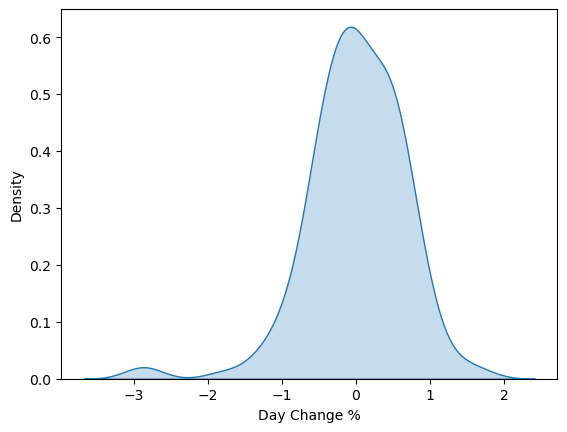

In [41]:
sns.kdeplot(sp['Day Change %'], shade=True)